# **Portfolio Risk Measurement using Value-at-Risk (VaR) and Conditional VaR(CVaR)**

**Step 0: Build the Environment**

Why it matters: This cell imports all the essential tools and libraries required for data analysis, calculation, and visualization, setting up the foundation for the entire project.

In [1]:
# --- Core Libraries for data manipulation and numerical operations ---
import pandas as pd
import numpy as np

# --- Library for downloading financial data ---
import yfinance as yf

# --- Libraries for creating charts and visualizations ---
import matplotlib.pyplot as plt
import seaborn as sns

# --- Library for advanced statistical functions, particularly for the normal distribution ---
from scipy.stats import norm

# --- Set default styles for our visualizations for a clean, professional look ---
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

**Step 1: Data Collection and Cleaning**

Why it matters: This step gathers all the necessary historical data for our selected stocks over the specified period (May 2019 to December 2024, the window where all 30 stocks have price history), ensuring we have a clean and reliable dataset which is the bedrock for our entire analysis.

In [2]:
# --- Define Stock Tickers by Risk Category ---
low_risk_tickers = ['JNJ', 'PG', 'KO', 'PEP', 'MCD', 'WMT', 'NEE', 'DUK', 'SO', 'AMT']
moderate_risk_tickers = ['JPM', 'BAC', 'GS', 'DIS', 'HD', 'CAT', 'GE', 'IBM', 'CSCO', 'HON']
high_risk_tickers = ['NVDA', 'TSLA', 'AMD', 'NFLX', 'PYPL', 'CRM', 'UBER', 'ZM', 'SHOP', 'MDB']
all_tickers = low_risk_tickers + moderate_risk_tickers + high_risk_tickers

# --- Set the full time period for data download ---
# Data is requested from 2000, but rows before every stock has history are dropped below,
# so the model is trained on May 2019 to December 2023 data and validated on 2024 data.
start_date = '2000-01-01'
end_date = '2024-12-31'

# --- Download Adjusted Close Prices ---
# We use auto_adjust=False to ensure the 'Adj Close' column is present, which is a robust method.
print("Downloading historical stock data...")
adj_close_df = yf.download(all_tickers, start=start_date, end=end_date, auto_adjust=False)['Adj Close']

# --- Data Cleaning and Inspection ---
# Check for any missing values and drop them. For a long period, it's possible some stocks
# weren't listed at the beginning, so we drop rows with any N/A values.
initial_rows = len(adj_close_df)
adj_close_df.dropna(inplace=True)
final_rows = len(adj_close_df)

print("\n--- Data Cleaning Summary ---")
print(f"Removed {initial_rows - final_rows} rows with missing data.")
print(f"Data now ranges from {adj_close_df.index.min().date()} to {adj_close_df.index.max().date()}.")

if adj_close_df.isnull().sum().sum() == 0:
    print("Data is clean. No missing values remain.")
else:
    print("Warning: Missing values still detected.")

print("\n--- Sample of Cleaned Stock Price Data ---")
print(adj_close_df.head())

[*********************100%***********************]  30 of 30 completed


--- Data Cleaning Summary ---
Removed 4868 rows with missing data.
Data now ranges from 2019-05-10 to 2024-12-30.
Data is clean. No missing values remain.

--- Sample of Cleaned Stock Price Data ---
Ticker            AMD         AMT        BAC         CAT         CRM  \
Date                                                                   
2019-05-10  27.959999  158.790482  24.693716  113.459778  156.943893   
2019-05-13  26.240000  159.780548  23.583424  108.242035  150.281082   
2019-05-14  27.320000  160.746323  23.892296  110.116631  155.108948   
2019-05-15  27.580000  162.694046  23.616816  109.969765  152.155304   
2019-05-16  28.010000  163.951981  23.867249  109.373703  155.511261   

Ticker           CSCO         DIS        DUK         GE          GS  ...  \
Date                                                                 ...   
2019-05-10  43.103271  128.391144  65.395264  48.755157  169.868469  ...   
2019-05-13  41.439247  125.804932  65.439835  47.503788  163.916199

**Step 2: Construct Portfolio, Analyze, and Split Data**

Why it matters: This cell translates the individual stock data into a single portfolio, analyzes its overall historical behavior, and then formally splits the data into a "training" period (for building the model) and a "validation" period (for testing it).

--- Portfolio Summary Statistics (Full Period) ---
                        Value
Metric                       
Mean Daily Return    0.000755
Standard Deviation   0.013681
Skewness            -0.356108
Kurtosis            13.844458


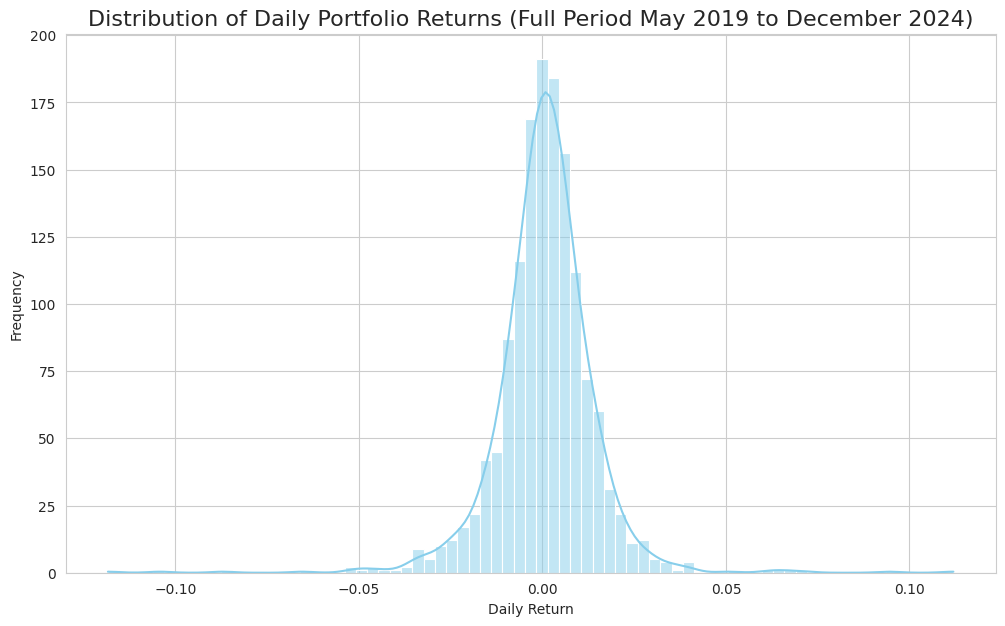


--- Data Splitting ---
Training data runs from 2019-05-13 to 2023-12-29.
Validation data runs from 2024-01-03 to 2024-12-30.


In [3]:
# --- Calculate Daily Returns for each stock ---
daily_returns_individual = adj_close_df.pct_change().dropna()

# --- Define and apply portfolio weights ---
# 60% low-risk, 30% moderate-risk, 10% high-risk
weights = []
weights.extend([0.06] * len(low_risk_tickers))
weights.extend([0.03] * len(moderate_risk_tickers))
weights.extend([0.01] * len(high_risk_tickers))
weights = np.array(weights)

# --- Calculate the daily returns of the entire portfolio ---
portfolio_returns = daily_returns_individual.dot(weights)

# --- Calculate Key Summary Statistics for the ENTIRE period ---
mean_return_full = portfolio_returns.mean()
std_dev_full = portfolio_returns.std()
skewness_full = portfolio_returns.skew()
kurtosis_full = portfolio_returns.kurtosis()

portfolio_stats_full = pd.DataFrame({
    'Metric': ['Mean Daily Return', 'Standard Deviation', 'Skewness', 'Kurtosis'],
    'Value': [mean_return_full, std_dev_full, skewness_full, kurtosis_full]
}).set_index('Metric')

print("--- Portfolio Summary Statistics (Full Period) ---")
print(portfolio_stats_full)

# --- Plot a histogram of the full period's returns ---
plt.figure(figsize=(12, 7))
sns.histplot(portfolio_returns, bins=75, kde=True, color='skyblue')
plt.title('Distribution of Daily Portfolio Returns (Full Period May 2019 to December 2024)', fontsize=16)
plt.xlabel('Daily Return')
plt.ylabel('Frequency')
plt.show()

# --- Split the data into Training and Validation sets ---
split_date = '2023-12-31'
training_returns = portfolio_returns[:split_date]
validation_returns = portfolio_returns[split_date:].iloc[1:]

print("\n--- Data Splitting ---")
print(f"Training data runs from {training_returns.index.min().date()} to {training_returns.index.max().date()}.")
print(f"Validation data runs from {validation_returns.index.min().date()} to {validation_returns.index.max().date()}.")

**Step 3: Calculate VaR and CVaR and Visualize Methods**

Why it matters: This crucial step calculates the core risk metrics (VaR and CVaR) using three different methodologies on our training data, providing distinct views on potential portfolio losses and visualizing each method's results.

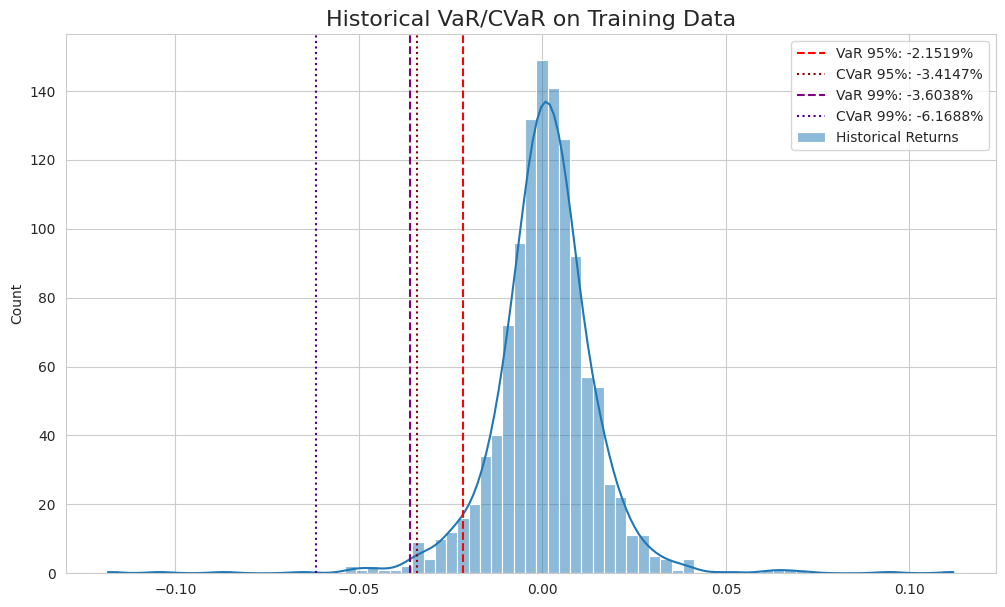

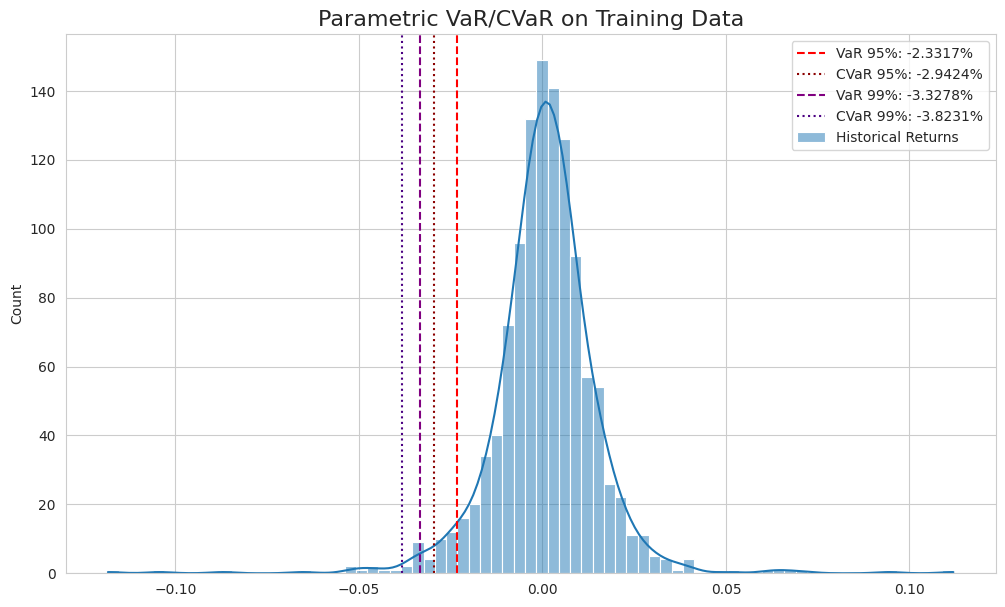

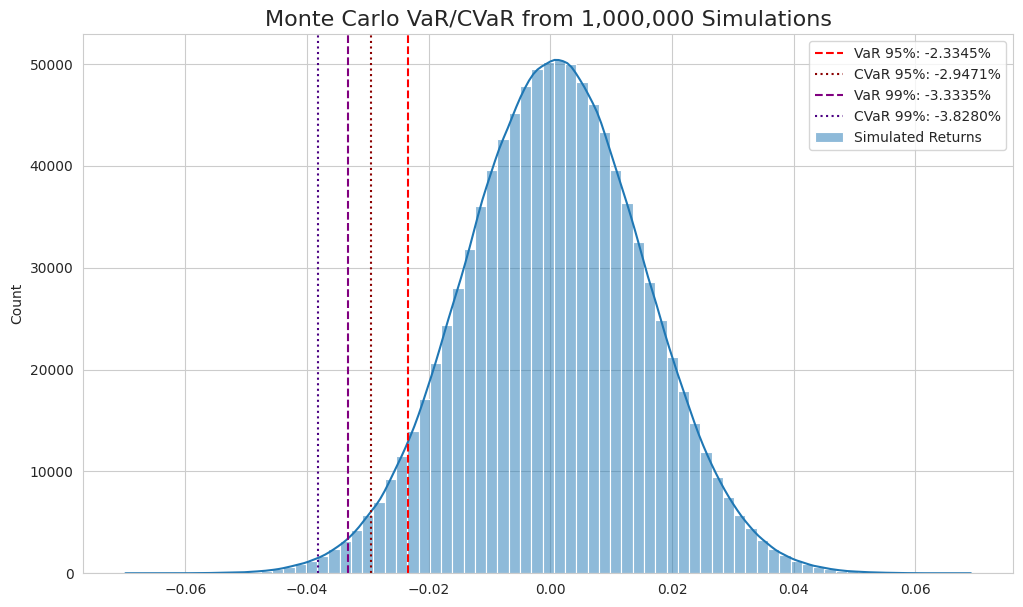

/tmp/ipykernel_2049/711920759.py:82: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_yticklabels(['{:,.2%}'.format(x) for x in vals])


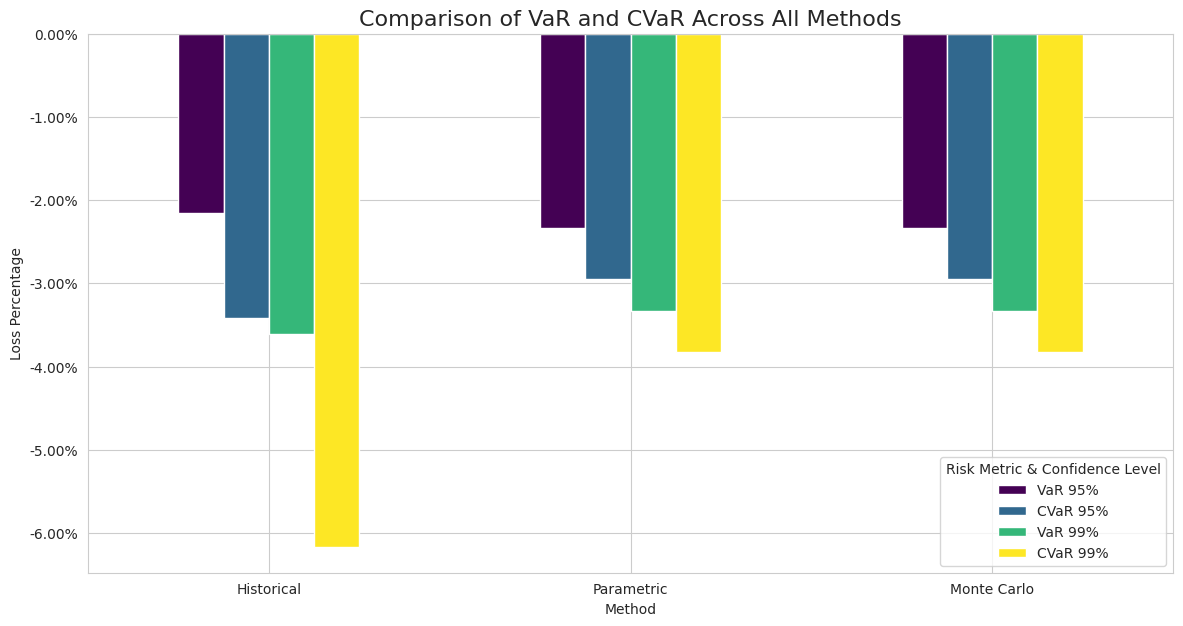

In [4]:
# --- Confidence Levels ---
confidence_level_95 = 0.95
confidence_level_99 = 0.99

# --- Method 1: Historical Simulation ---
hist_var_95 = training_returns.quantile(1 - confidence_level_95)
hist_cvar_95 = training_returns[training_returns <= hist_var_95].mean()
hist_var_99 = training_returns.quantile(1 - confidence_level_99)
hist_cvar_99 = training_returns[training_returns <= hist_var_99].mean()

# --- Method 2: Parametric (Variance-Covariance) ---
mean_train = training_returns.mean()
std_train = training_returns.std()
z_score_95 = norm.ppf(1 - confidence_level_95)
z_score_99 = norm.ppf(1 - confidence_level_99)
param_var_95 = mean_train + z_score_95 * std_train
param_var_99 = mean_train + z_score_99 * std_train
param_cvar_95 = mean_train - std_train * (norm.pdf(z_score_95) / (1 - confidence_level_95))
param_cvar_99 = mean_train - std_train * (norm.pdf(z_score_99) / (1 - confidence_level_99))

# --- Method 3: Monte Carlo Simulation ---
np.random.seed(42)  # fixed seed so the Monte Carlo numbers repeat
num_simulations = 1000000
simulated_returns = np.random.normal(mean_train, std_train, num_simulations)
mc_var_95 = np.percentile(simulated_returns, 100 * (1 - confidence_level_95))
mc_cvar_95 = simulated_returns[simulated_returns <= mc_var_95].mean()
mc_var_99 = np.percentile(simulated_returns, 100 * (1 - confidence_level_99))
mc_cvar_99 = simulated_returns[simulated_returns <= mc_var_99].mean()

# --- VISUALIZATIONS FOR EACH METHOD ---

# 1. Historical Visualization
plt.figure(figsize=(12, 7))
sns.histplot(training_returns, bins=75, kde=True, label='Historical Returns')
plt.axvline(hist_var_95, color='red', linestyle='--', label=f'VaR 95%: {hist_var_95:.4%}')
plt.axvline(hist_cvar_95, color='darkred', linestyle=':', label=f'CVaR 95%: {hist_cvar_95:.4%}')
plt.axvline(hist_var_99, color='purple', linestyle='--', label=f'VaR 99%: {hist_var_99:.4%}')
plt.axvline(hist_cvar_99, color='indigo', linestyle=':', label=f'CVaR 99%: {hist_cvar_99:.4%}')
plt.title('Historical VaR/CVaR on Training Data', fontsize=16)
plt.legend()
plt.show()

# 2. Parametric Visualization (overlaying on historical data)
plt.figure(figsize=(12, 7))
sns.histplot(training_returns, bins=75, kde=True, label='Historical Returns')
plt.axvline(param_var_95, color='red', linestyle='--', label=f'VaR 95%: {param_var_95:.4%}')
plt.axvline(param_cvar_95, color='darkred', linestyle=':', label=f'CVaR 95%: {param_cvar_95:.4%}')
plt.axvline(param_var_99, color='purple', linestyle='--', label=f'VaR 99%: {param_var_99:.4%}')
plt.axvline(param_cvar_99, color='indigo', linestyle=':', label=f'CVaR 99%: {param_cvar_99:.4%}')
plt.title('Parametric VaR/CVaR on Training Data', fontsize=16)
plt.legend()
plt.show()

# 3. Monte Carlo Visualization
plt.figure(figsize=(12, 7))
sns.histplot(simulated_returns, bins=75, kde=True, label='Simulated Returns')
plt.axvline(mc_var_95, color='red', linestyle='--', label=f'VaR 95%: {mc_var_95:.4%}')
plt.axvline(mc_cvar_95, color='darkred', linestyle=':', label=f'CVaR 95%: {mc_cvar_95:.4%}')
plt.axvline(mc_var_99, color='purple', linestyle='--', label=f'VaR 99%: {mc_var_99:.4%}')
plt.axvline(mc_cvar_99, color='indigo', linestyle=':', label=f'CVaR 99%: {mc_cvar_99:.4%}')
plt.title('Monte Carlo VaR/CVaR from 1,000,000 Simulations', fontsize=16)
plt.legend()
plt.show()


# --- Final Comparison Bar Chart ---
summary_data = {
    'Method': ['Historical', 'Parametric', 'Monte Carlo'],
    'VaR 95%': [hist_var_95, param_var_95, mc_var_95],
    'CVaR 95%': [hist_cvar_95, param_cvar_95, mc_cvar_95],
    'VaR 99%': [hist_var_99, param_var_99, mc_var_99],
    'CVaR 99%': [hist_cvar_99, param_cvar_99, mc_cvar_99],
}
summary_df = pd.DataFrame(summary_data).set_index('Method')

summary_df.plot(kind='bar', figsize=(14, 7), colormap='viridis')
plt.title('Comparison of VaR and CVaR Across All Methods', fontsize=16)
plt.ylabel('Loss Percentage')
plt.xlabel('Method')
plt.xticks(rotation=0)
vals = plt.gca().get_yticks()
plt.gca().set_yticklabels(['{:,.2%}'.format(x) for x in vals])
plt.legend(title='Risk Metric & Confidence Level')
plt.show()

**Step 4: Backtesting the VaR Model**

Why it matters: This is the verification step; it provides objective evidence on whether our risk models (built on May 2019 to December 2023 data) were accurate by comparing their predictions to the actual market outcomes of 2024.

In [5]:
# --- Count actual breaches in the validation period (2024) ---
# A breach occurs if the actual loss is greater than the predicted VaR loss.
actual_breaches_hist_95 = (validation_returns < hist_var_95).sum()
actual_breaches_param_95 = (validation_returns < param_var_95).sum()
actual_breaches_mc_95 = (validation_returns < mc_var_95).sum()

actual_breaches_hist_99 = (validation_returns < hist_var_99).sum()
actual_breaches_param_99 = (validation_returns < param_var_99).sum()
actual_breaches_mc_99 = (validation_returns < mc_var_99).sum()

# --- Calculate the expected number of breaches ---
num_validation_days = len(validation_returns)
expected_breaches_95 = (1 - confidence_level_95) * num_validation_days
expected_breaches_99 = (1 - confidence_level_99) * num_validation_days

# --- Create and display the backtesting summary table ---
backtesting_results = pd.DataFrame({
    'VaR Confidence Level': ['95%', '95%', '95%', '99%', '99%', '99%'],
    'Method': ['Historical', 'Parametric', 'Monte Carlo', 'Historical', 'Parametric', 'Monte Carlo'],
    'Expected Breaches': [expected_breaches_95, expected_breaches_95, expected_breaches_95, expected_breaches_99, expected_breaches_99, expected_breaches_99],
    'Actual Breaches': [actual_breaches_hist_95, actual_breaches_param_95, actual_breaches_mc_95, actual_breaches_hist_99, actual_breaches_param_99, actual_breaches_mc_99],
}).set_index(['VaR Confidence Level', 'Method'])

print("--- VaR Backtesting Results for 2024 ---")
print(backtesting_results)

--- VaR Backtesting Results for 2024 ---
                                  Expected Breaches  Actual Breaches
VaR Confidence Level Method                                         
95%                  Historical                12.5                2
                     Parametric                12.5                1
                     Monte Carlo               12.5                1
99%                  Historical                 2.5                0
                     Parametric                 2.5                0
                     Monte Carlo                2.5                0


**Step 5: Consolidation and Final Visualization (with 95% and 99% Breaches)**

Why it matters: This final step consolidates our key findings into clear summary tables and provides a powerful visualization of the backtest, showing exactly when and how often the portfolio's losses breached both the 95% and the more extreme 99% predicted risk thresholds in 2024.


--- Summary of VaR and CVaR Risk Metrics (based on May 2019 to December 2023 data) ---


,VaR 95%,CVaR 95%,VaR 99%,CVaR 99%
Method,,,,
Historical,-2.1519%,-3.4147%,-3.6038%,-6.1688%
Parametric,-2.3317%,-2.9424%,-3.3278%,-3.8231%
Monte Carlo,-2.3345%,-2.9471%,-3.3335%,-3.8280%



--- Summary of VaR Backtesting Results for 2024 ---


Expected Breaches  Actual Breaches
VaR Confidence Level Method                                         
95%                  Historical                12.5                2
                     Parametric                12.5                1
                     Monte Carlo               12.5                1
99%                  Historical                 2.5                0
                     Parametric                 2.5                0
                     Monte Carlo                2.5                0

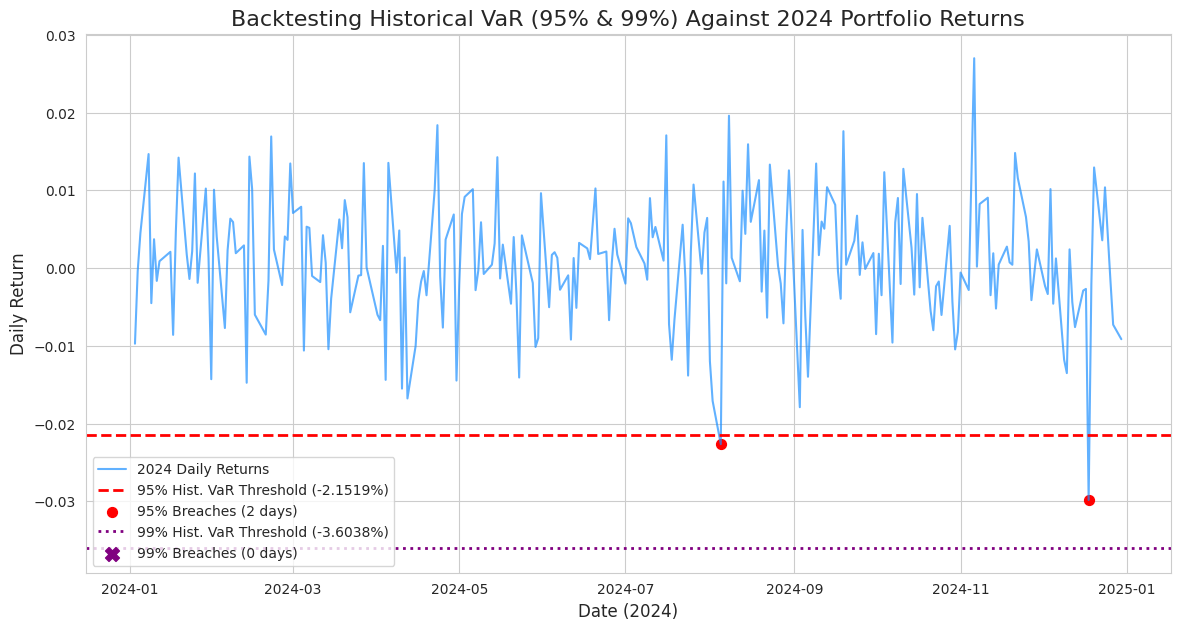

In [6]:
# --- Table 1: Final Summary of VaR and CVaR Values ---
# This table shows the risk metrics calculated from the May 2019 to December 2023 training data.
print("\n--- Summary of VaR and CVaR Risk Metrics (based on May 2019 to December 2023 data) ---")
display(summary_df.style.format("{:.4%}"))

# --- Table 2: Final Backtesting Results ---
# This table shows how the models performed when tested against 2024 data.
print("\n--- Summary of VaR Backtesting Results for 2024 ---")
display(backtesting_results)

# --- Final Visualization: Plotting 95% and 99% Breaches in the Validation Period ---
# This chart provides visual proof of the backtesting results.
plt.figure(figsize=(14, 7))
plt.plot(validation_returns.index, validation_returns, color='dodgerblue', alpha=0.7, label='2024 Daily Returns')

# --- Plot 95% VaR and its Breaches ---
plt.axhline(hist_var_95, color='red', linestyle='--', linewidth=2, label=f'95% Hist. VaR Threshold ({hist_var_95:.4%})')
breaches_95 = validation_returns[validation_returns < hist_var_95]
plt.scatter(breaches_95.index, breaches_95, color='red', marker='o', s=50, label=f'95% Breaches ({len(breaches_95)} days)')

# --- Plot 99% VaR and its Breaches ---
plt.axhline(hist_var_99, color='purple', linestyle=':', linewidth=2, label=f'99% Hist. VaR Threshold ({hist_var_99:.4%})')
breaches_99 = validation_returns[validation_returns < hist_var_99]
# We use a different marker ('X') and a higher zorder to ensure 99% breaches are visible on top of 95% breaches.
plt.scatter(breaches_99.index, breaches_99, color='purple', marker='X', s=100, label=f'99% Breaches ({len(breaches_99)} days)', zorder=5)

# --- Final Chart Formatting ---
plt.title('Backtesting Historical VaR (95% & 99%) Against 2024 Portfolio Returns', fontsize=16)
plt.xlabel('Date (2024)', fontsize=12)
plt.ylabel('Daily Return', fontsize=12)
plt.legend()
plt.show()